In [5]:
# Cell 0 — Setup and core tables

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[2]
except NameError:
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT.name != "drug-discovery-lohi" and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent

DATASETS = ["drd2", "hiv", "sol"]
DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "sol": "Sol"}
FOLDS = [1, 2, 3]
TOP_K_VALUES = [10, 20, 50, 100, 150, 200]
FP_MAIN = "ECFP4"

OOD_RANDOM_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / "hi"
    / "cross_dataset"
)

SHIFT_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_classifier_shift_test"
    / "hi"
)

FIG_DIR = OOD_RANDOM_DIR / "figures_diagnostic_notebook"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def read_csv(path, name, required=True):
    if path.exists():
        df = pd.read_csv(path)
        print(f"Loaded {name}: {df.shape}")
        return df
    if required:
        raise FileNotFoundError(f"Missing required file: {path}")
    print(f"Optional file not found: {name}")
    return None

per_fold = read_csv(OOD_RANDOM_DIR / "cross_dataset_protocol_per_fold.csv", "per_fold")
summary = read_csv(OOD_RANDOM_DIR / "cross_dataset_protocol_summary.csv", "summary")
delta = read_csv(OOD_RANDOM_DIR / "cross_dataset_protocol_delta.csv", "delta")
fi_all = read_csv(OOD_RANDOM_DIR / "cross_dataset_feature_importance_all.csv", "feature_importance_all")
ood_random_overlap = read_csv(OOD_RANDOM_DIR / "cross_dataset_feature_overlap.csv", "ood_random_feature_overlap")

listA_listB_overlap = read_csv(
    SHIFT_DIR / "cross_dataset_listA_listB_overlap_by_protocol_foldaware_multi_k.csv",
    "listA_listB_overlap",
    required=False,
)

# Keep only valid Hi datasets.
for name in ["per_fold", "summary", "delta", "fi_all", "ood_random_overlap"]:
    df = globals()[name]
    if "dataset" in df.columns:
        globals()[name] = df[df["dataset"].isin(DATASETS)].copy()

if listA_listB_overlap is not None and "dataset" in listA_listB_overlap.columns:
    listA_listB_overlap = listA_listB_overlap[
        listA_listB_overlap["dataset"].isin(DATASETS)
    ].copy()

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 9.5,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
})

print("\nProject root:", PROJECT_ROOT)
print("Figure dir:", FIG_DIR)
print("Datasets:", DATASETS)

Loaded per_fold: (126, 17)
Loaded summary: (42, 20)
Loaded delta: (21, 20)
Loaded feature_importance_all: (123516, 28)
Loaded ood_random_feature_overlap: (378, 16)
Loaded listA_listB_overlap: (648, 14)

Project root: /home/f.capria/drug-discovery-lohi
Figure dir: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/figures_diagnostic_notebook
Datasets: ['drd2', 'hiv', 'sol']


/tmp/ipykernel_3563857/689707250.py:43: DtypeWarning: Columns (0: used_in_tree, 1: permutation_scoring, 2: permutation_eval_set) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [8]:
# Cell 1 — Class balance sanity check on Hi test folds

rows = []

for dataset in DATASETS:
    for test_id in [1, 2, 3]:
        path = PROJECT_ROOT / "data" / "hi" / dataset / f"test_{test_id}.csv"
        df = pd.read_csv(path)

        y = df["value"].astype(int)

        rows.append({
            "dataset": DATASET_LABELS.get(dataset, dataset.upper()),
            "test_fold": f"test_{test_id}",
            "n": len(y),
            "negatives": int((y == 0).sum()),
            "positives": int((y == 1).sum()),
            "positive_rate": float((y == 1).mean()),
        })

class_balance = pd.DataFrame(rows)

display(
    class_balance.style.format({
        "positive_rate": "{:.3f}",
    })
)

,dataset,test_fold,n,negatives,positives,positive_rate
0,DRD2,test_1,1190,455,735,0.618
1,DRD2,test_2,1194,285,909,0.761
2,DRD2,test_3,1191,416,775,0.651
3,HIV,test_1,7847,7507,340,0.043
4,HIV,test_2,7848,7413,435,0.055
5,HIV,test_3,7848,7684,164,0.021
6,Sol,test_1,721,563,158,0.219
7,Sol,test_2,721,560,161,0.223
8,Sol,test_3,721,574,147,0.204


Saved: step1_class_balance_test_folds.png
Saved: step1_class_balance_test_folds.pdf


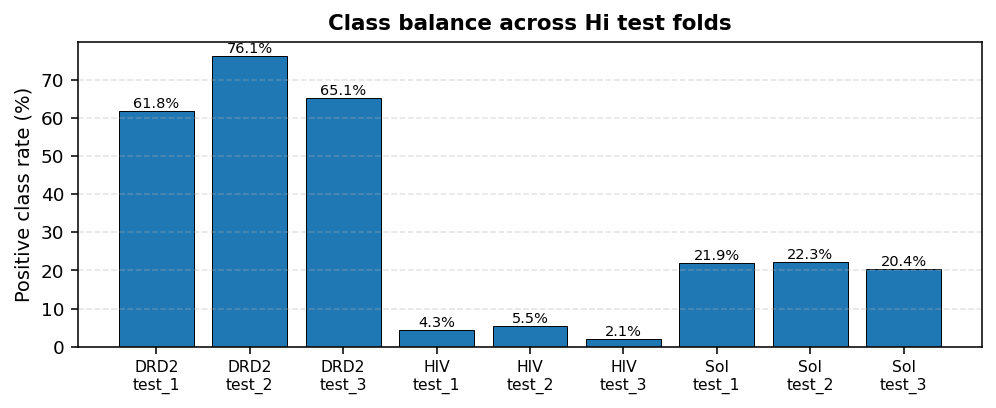

In [9]:
# Compact plot

plot_df = class_balance.copy()
plot_df["x_label"] = plot_df["dataset"] + "\n" + plot_df["test_fold"]

fig, ax = plt.subplots(figsize=(7.2, 3.0))

ax.bar(
    np.arange(len(plot_df)),
    100 * plot_df["positive_rate"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xticks(np.arange(len(plot_df)))
ax.set_xticklabels(plot_df["x_label"], fontsize=8)
ax.set_ylabel("Positive class rate (%)")
ax.set_title("Class balance across Hi test folds", fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.35)

for i, r in plot_df.iterrows():
    ax.text(
        i,
        100 * r["positive_rate"],
        f"{100 * r['positive_rate']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )

fig.tight_layout()

fname_png = FIG_DIR / "step1_class_balance_test_folds.png"
fname_pdf = FIG_DIR / "step1_class_balance_test_folds.pdf"

fig.savefig(fname_png, dpi=300, bbox_inches="tight")
fig.savefig(fname_pdf, bbox_inches="tight")

print(f"Saved: {fname_png.name}")
print(f"Saved: {fname_pdf.name}")

plt.show()

### This sanity check shows that class priors are not equally stable across datasets. Sol has a relatively consistent positive rate across test folds, while DRD2 shows a moderate fold-dependent change in positive prevalence. HIV is strongly imbalanced overall and test_3 has a substantially lower positive rate than the other folds. Therefore, part of the observed OOD behavior, especially for HIV, may be influenced by prior shift P(Y), not only by covariate shift in molecular structure.

## Feature-ranking stability across folds

### Do models trained on different outer folds rely on similar activity-relevant features?

In [17]:
# Cell 2b — Cumulative top-k feature-ranking stability across folds
# Question: does feature-ranking stability increase as we include more top-ranked features?

K_VALUES_STABILITY = [10, 20, 50, 100, 150, 200]
N_ECFP4_BITS = 2048
MAIN_PROTOCOL = "OOD holdout"

df = fi_all[
    (fi_all["fingerprint"] == "ECFP4")
    & (fi_all["protocol"] == MAIN_PROTOCOL)
    & (fi_all["dataset"].isin(DATASETS))
].copy()

df["feature_idx"] = df["feature_idx"].astype(int)
df["importance_rank"] = pd.to_numeric(df["importance_rank"], errors="coerce")

if "model_short" not in df.columns:
    model_map = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
    }
    df["model_short"] = df["model"].map(model_map).fillna(df["model"].astype(str))

rows = []

for (dataset, model_short), sub in df.groupby(["dataset", "model_short"]):
    fold_rankings = {}

    for fold in FOLDS:
        fold_rankings[fold] = (
            sub[sub["fold"] == fold]
            .dropna(subset=["importance_rank"])
            .sort_values("importance_rank")
            ["feature_idx"]
            .astype(int)
            .tolist()
        )

    for f1, f2 in combinations(FOLDS, 2):
        for k in K_VALUES_STABILITY:
            top1 = set(fold_rankings[f1][:k])
            top2 = set(fold_rankings[f2][:k])

            n_common = len(top1 & top2)
            n_union = len(top1 | top2)

            rows.append({
                "dataset": dataset,
                "dataset_label": DATASET_LABELS.get(dataset, dataset.upper()),
                "model_short": model_short,
                "fold_pair": f"{f1} vs {f2}",
                "k": k,
                "n_common": n_common,
                "overlap_percent": 100 * n_common / k,
                "jaccard_percent": 100 * n_common / n_union if n_union > 0 else np.nan,
                "random_expected_percent": 100 * k / N_ECFP4_BITS,
            })

feature_stability_curve = pd.DataFrame(rows)

display(
    feature_stability_curve.head().style.format({
        "overlap_percent": "{:.1f}",
        "jaccard_percent": "{:.1f}",
        "random_expected_percent": "{:.2f}",
    })
)

,dataset,dataset_label,model_short,fold_pair,k,n_common,overlap_percent,jaccard_percent,random_expected_percent
0,drd2,DRD2,DT,1 vs 2,10,0,0.0,0.0,0.49
1,drd2,DRD2,DT,1 vs 2,20,1,5.0,2.6,0.98
2,drd2,DRD2,DT,1 vs 2,50,2,4.0,2.0,2.44
3,drd2,DRD2,DT,1 vs 2,100,45,45.0,29.0,4.88
4,drd2,DRD2,DT,1 vs 2,150,97,64.7,47.8,7.32


Saved: step2b_cumulative_feature_ranking_stability.png
Saved: step2b_cumulative_feature_ranking_stability.pdf


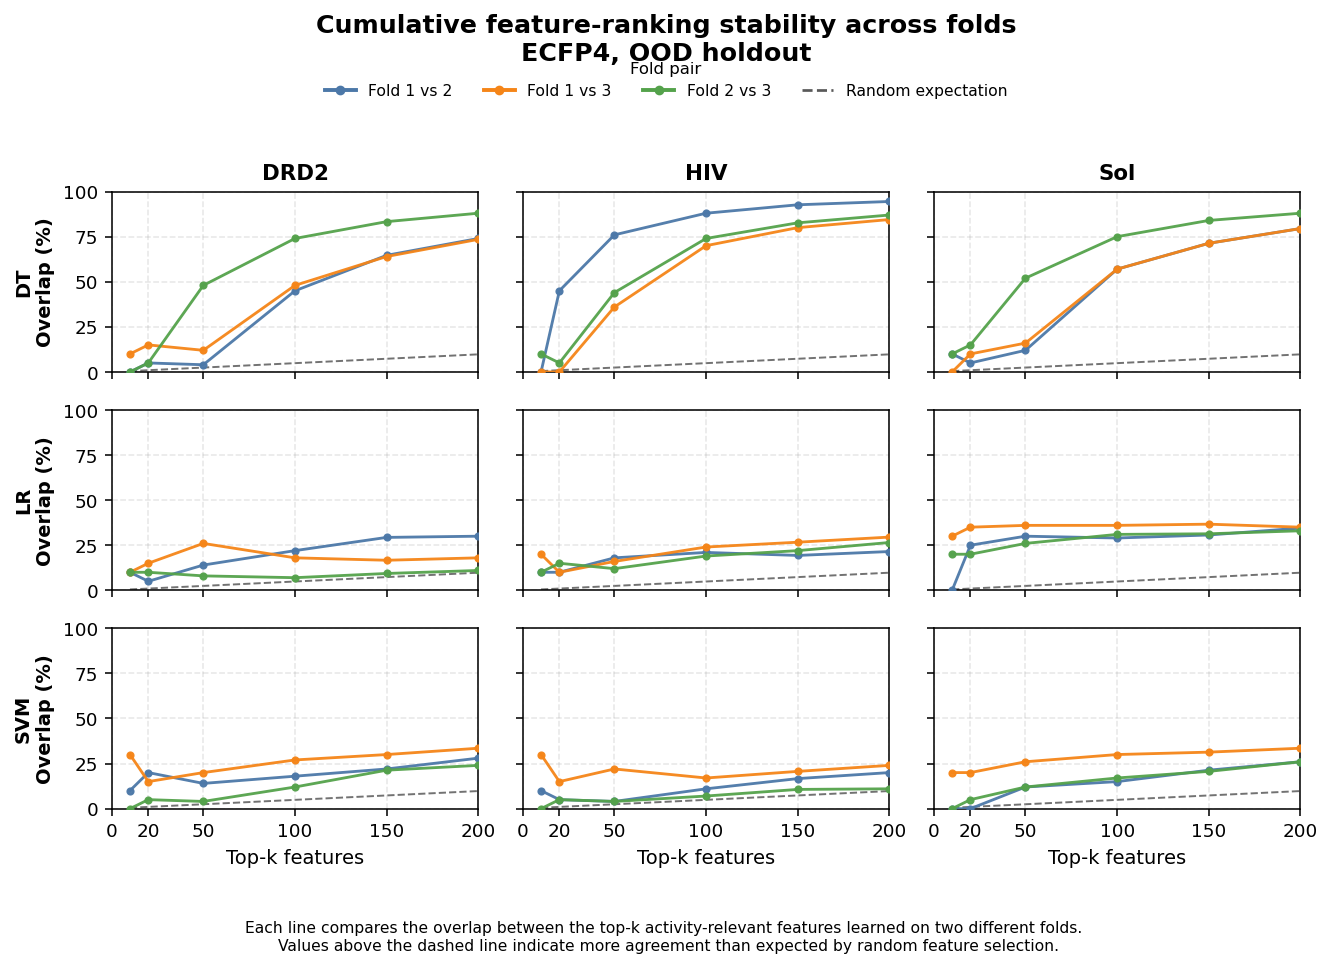

In [ ]:
model_order = ["DT", "LR", "SVM"]
dataset_order = DATASETS

pair_order = ["1 vs 2", "1 vs 3", "2 vs 3"]

pair_colors = {
    "1 vs 2": "#4C78A8",
    "1 vs 3": "#F58518",
    "2 vs 3": "#54A24B",
}

fig, axes = plt.subplots(
    len(model_order),
    len(dataset_order),
    figsize=(9.6, 6.0),
    sharex=True,
    sharey=True,
    squeeze=False,
)

y_max = min(
    100,
    max(20, 1.15 * feature_stability_curve["overlap_percent"].max())
)

for i, model in enumerate(model_order):
    for j, dataset in enumerate(dataset_order):
        ax = axes[i, j]

        panel = feature_stability_curve[
            (feature_stability_curve["dataset"] == dataset)
            & (feature_stability_curve["model_short"] == model)
        ].copy()

        # Random expectation baseline.
        expected = (
            panel[["k", "random_expected_percent"]]
            .drop_duplicates()
            .sort_values("k")
        )

        ax.plot(
            expected["k"],
            expected["random_expected_percent"],
            color="0.35",
            linestyle="--",
            linewidth=1.0,
            alpha=0.85,
            zorder=1,
        )

        for pair in pair_order:
            sub = panel[panel["fold_pair"] == pair].sort_values("k")

            if sub.empty:
                continue

            ax.plot(
                sub["k"],
                sub["overlap_percent"],
                marker="o",
                markersize=3.2,
                linewidth=1.45,
                color=pair_colors[pair],
                alpha=0.95,
                zorder=3,
            )

        ax.set_xlim(0, 200)
        ax.set_xticks([0, 20, 50, 100, 150, 200])
        ax.set_ylim(0, y_max)
        ax.grid(linestyle="--", alpha=0.30)

        if i == 0:
            ax.set_title(
                DATASET_LABELS.get(dataset, dataset.upper()),
                fontweight="bold",
            )

        if j == 0:
            ax.set_ylabel(f"{model}\nOverlap (%)", fontweight="bold")

        if i == len(model_order) - 1:
            ax.set_xlabel("Top-k features")

fold_handles = [
    Line2D(
        [0],
        [0],
        color=pair_colors[pair],
        marker="o",
        linewidth=2.0,
        markersize=4.0,
        label=f"Fold {pair}",
    )
    for pair in pair_order
]

random_handle = Line2D(
    [0],
    [0],
    color="0.35",
    linestyle="--",
    linewidth=1.4,
    label="Random expectation",
)

fig.legend(
    handles=fold_handles + [random_handle],
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.015),
    title="Fold pair",
    fontsize=8,
    title_fontsize=8.5,
)

fig.suptitle(
    "Cumulative feature-ranking stability across folds\nECFP4, OOD holdout",
    fontweight="bold",
    fontsize=13,
    y=1.055,
)

fig.text(
    0.5,
    -0.025,
    "Each line compares the overlap between the top-k activity-relevant features learned on two different folds. \n "
    "Values above the dashed line indicate more agreement than expected by random feature selection.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.tight_layout(rect=[0, 0.015, 1, 0.985])

fname_png = FIG_DIR / "step2b_cumulative_feature_ranking_stability.png"
fname_pdf = FIG_DIR / "step2b_cumulative_feature_ranking_stability.pdf"

fig.savefig(fname_png, dpi=300, bbox_inches="tight")
fig.savefig(fname_pdf, bbox_inches="tight")

print(f"Saved: {fname_png.name}")
print(f"Saved: {fname_pdf.name}")

plt.show()

### Il grafico mostra che la stabilità delle feature importanti dipende molto dal modello. I Decision Tree recuperano insiemi di feature molto simili tra fold quando si aumenta k, mentre LR e SVM mostrano overlap più basso e quindi un uso più fold-specific delle feature. Questo non dimostra direttamente concept shift, perché molte feature ECFP4 possono essere correlate o sostituibili, ma indica che la regola appresa dai modelli lineari è meno stabile tra fold.

# Cumulative Kendall Tau of feature-importance rankings across folds

do different training folds rank the important features in the same order?

In [20]:

from scipy.stats import kendalltau
from itertools import combinations

K_VALUES_TAU = [10, 20, 50, 100, 150, 200]
MAIN_PROTOCOL = "OOD holdout"

df = fi_all[
    (fi_all["fingerprint"] == "ECFP4")
    & (fi_all["protocol"] == MAIN_PROTOCOL)
    & (fi_all["dataset"].isin(DATASETS))
].copy()

df["feature_idx"] = df["feature_idx"].astype(int)
df["importance_rank"] = pd.to_numeric(df["importance_rank"], errors="coerce")
df["fold"] = df["fold"].astype(int)

if "model_short" not in df.columns:
    model_map = {
        "Decision Tree": "DT",
        "Logistic Regression": "LR",
        "Linear SVM": "SVM",
        "DT": "DT",
        "LR": "LR",
        "SVM": "SVM",
    }
    df["model_short"] = df["model"].map(model_map).fillna(df["model"].astype(str))

rows = []

for (dataset, model_short), sub in df.groupby(["dataset", "model_short"]):
    fold_rankings = {}

    for fold in FOLDS:
        s = (
            sub[sub["fold"] == fold]
            .dropna(subset=["importance_rank"])
            .sort_values("importance_rank")
            [["feature_idx", "importance_rank"]]
            .copy()
        )

        fold_rankings[fold] = s

    for f1, f2 in combinations(FOLDS, 2):
        r1 = fold_rankings[f1]
        r2 = fold_rankings[f2]

        rank1_full = r1.set_index("feature_idx")["importance_rank"].to_dict()
        rank2_full = r2.set_index("feature_idx")["importance_rank"].to_dict()

        for k in K_VALUES_TAU:
            top1 = set(r1.head(k)["feature_idx"])
            top2 = set(r2.head(k)["feature_idx"])

            # Union of relevant top-k features from the two folds.
            union_feats = sorted(top1 | top2)

            if len(union_feats) < 2:
                tau = np.nan
            else:
                # Features absent from a fold top-k are assigned rank k+1.
                # This makes the metric focus on the top-k region.
                v1 = [rank1_full.get(feat, k + 1) for feat in union_feats]
                v2 = [rank2_full.get(feat, k + 1) for feat in union_feats]

                tau = kendalltau(v1, v2, nan_policy="omit").statistic

            rows.append({
                "dataset": dataset,
                "dataset_label": DATASET_LABELS.get(dataset, dataset.upper()),
                "model_short": model_short,
                "fold_pair": f"{f1} vs {f2}",
                "k": k,
                "kendall_tau": tau,
            })

feature_tau_curve = pd.DataFrame(rows)

display(
    feature_tau_curve.head().style.format({
        "kendall_tau": "{:.3f}",
    })
)

,dataset,dataset_label,model_short,fold_pair,k,kendall_tau
0,drd2,DRD2,DT,1 vs 2,10,-0.547
1,drd2,DRD2,DT,1 vs 2,20,-0.471
2,drd2,DRD2,DT,1 vs 2,50,-0.324
3,drd2,DRD2,DT,1 vs 2,100,-0.105
4,drd2,DRD2,DT,1 vs 2,150,0.078


Saved: step2c_cumulative_kendall_tau_feature_rankings.png
Saved: step2c_cumulative_kendall_tau_feature_rankings.pdf


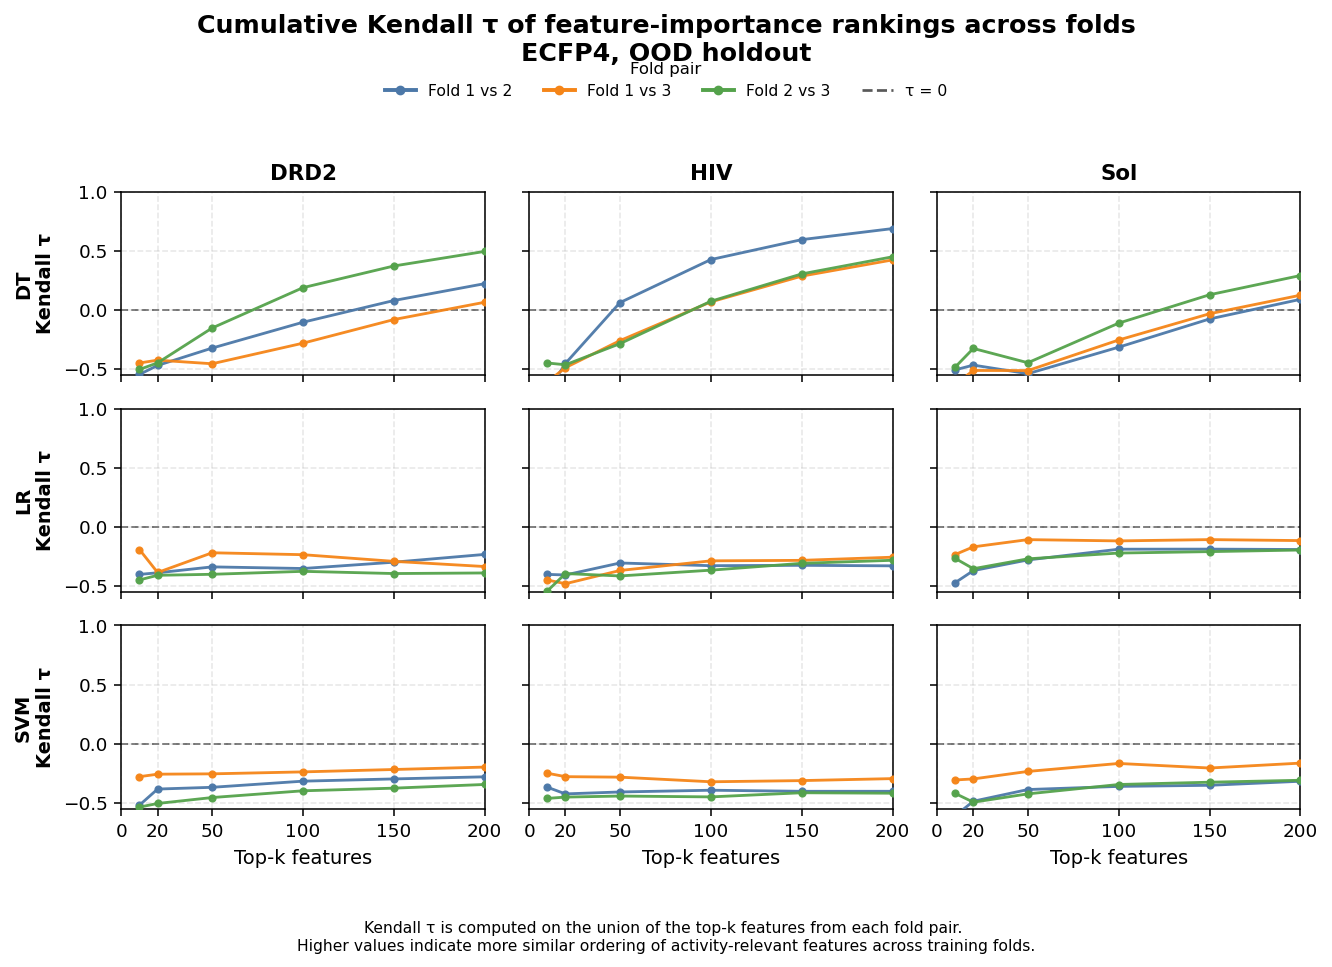

In [22]:

model_order = ["DT", "LR", "SVM"]
dataset_order = DATASETS

pair_order = ["1 vs 2", "1 vs 3", "2 vs 3"]

pair_colors = {
    "1 vs 2": "#4C78A8",
    "1 vs 3": "#F58518",
    "2 vs 3": "#54A24B",
}

fig, axes = plt.subplots(
    len(model_order),
    len(dataset_order),
    figsize=(9.6, 6.0),
    sharex=True,
    sharey=True,
    squeeze=False,
)

for i, model in enumerate(model_order):
    for j, dataset in enumerate(dataset_order):
        ax = axes[i, j]

        panel = feature_tau_curve[
            (feature_tau_curve["dataset"] == dataset)
            & (feature_tau_curve["model_short"] == model)
        ].copy()

        ax.axhline(
            0,
            color="0.35",
            linestyle="--",
            linewidth=1.0,
            alpha=0.85,
            zorder=1,
        )

        for pair in pair_order:
            sub = panel[panel["fold_pair"] == pair].sort_values("k")

            if sub.empty:
                continue

            ax.plot(
                sub["k"],
                sub["kendall_tau"],
                marker="o",
                markersize=3.2,
                linewidth=1.45,
                color=pair_colors[pair],
                alpha=0.95,
                zorder=3,
            )

        ax.set_xlim(0, 200)
        ax.set_xticks([0, 20, 50, 100, 150, 200])
        ax.set_ylim(-0.55, 1.0)
        ax.grid(linestyle="--", alpha=0.30)

        if i == 0:
            ax.set_title(
                DATASET_LABELS.get(dataset, dataset.upper()),
                fontweight="bold",
            )

        if j == 0:
            ax.set_ylabel(f"{model}\nKendall τ", fontweight="bold")

        if i == len(model_order) - 1:
            ax.set_xlabel("Top-k features")

fold_handles = [
    Line2D(
        [0],
        [0],
        color=pair_colors[pair],
        marker="o",
        linewidth=2.0,
        markersize=4.0,
        label=f"Fold {pair}",
    )
    for pair in pair_order
]

zero_handle = Line2D(
    [0],
    [0],
    color="0.35",
    linestyle="--",
    linewidth=1.4,
    label="τ = 0",
)

fig.legend(
    handles=fold_handles + [zero_handle],
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.015),
    title="Fold pair",
    fontsize=8,
    title_fontsize=8.5,
)

fig.suptitle(
    "Cumulative Kendall τ of feature-importance rankings across folds\nECFP4, OOD holdout",
    fontweight="bold",
    fontsize=13,
    y=1.055,
)

fig.text(
    0.5,
    -0.025,
    "Kendall τ is computed on the union of the top-k features from each fold pair. \n"
    "Higher values indicate more similar ordering of activity-relevant features across training folds.",
    ha="center",
    va="top",
    fontsize=8,
)

fig.tight_layout(rect=[0, 0.015, 1, 0.985])

fname_png = FIG_DIR / "step2c_cumulative_kendall_tau_feature_rankings.png"
fname_pdf = FIG_DIR / "step2c_cumulative_kendall_tau_feature_rankings.pdf"

fig.savefig(fname_png, dpi=300, bbox_inches="tight")
fig.savefig(fname_pdf, bbox_inches="tight")

print(f"Saved: {fname_png.name}")
print(f"Saved: {fname_pdf.name}")

plt.show()

### L’analisi Kendall τ mostra che la stabilità del ranking dipende molto dal modello. I Decision Tree mostrano un accordo crescente tra fold al crescere di k, suggerendo una regola activity-relevant più stabile. Al contrario, LR e SVM hanno τ basso o negativo, indicando che l’ordinamento delle feature importanti è molto fold-specific. Questo è compatibile con possibile conditional instability, ma non dimostra direttamente concept shift, perché feature ECFP4 correlate possono essere scambiate tra loro dai modelli lineari.